## visualizations
#### ordered by appearance in article

### Figure 01: Frequency of keyword matches
#### includes
- creation of bar-plot
- styling of bar-plot
#### csv-file
- contains categories for and amount of search terms

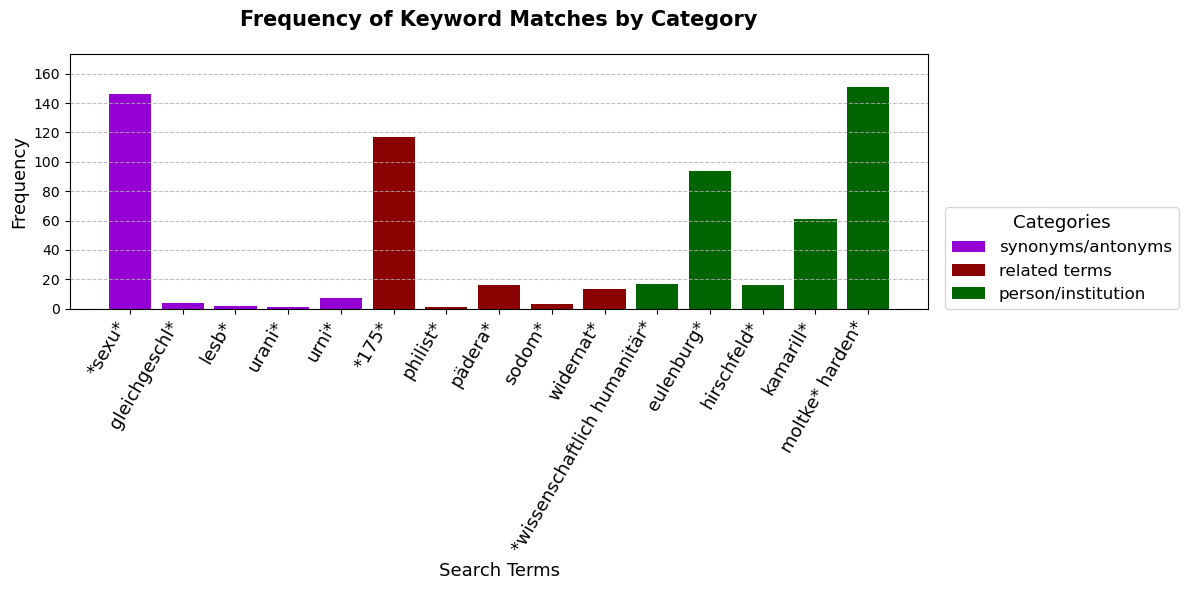

In [11]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df = pd.read_csv("search_terms.csv", sep=";")

# order of categories
category_order = ["synonyms/antonyms", "related terms", "person/institution"]

df["category"] = pd.Categorical(
    df["category"],
    categories=category_order,
    ordered=True
)

# ordered alphabetically per category
df = df.sort_values(by=["category", "search_term"])

# color coding
colour_dict = {
    "synonyms/antonyms": "darkviolet",
    "related terms": "darkred",
    "person/institution": "darkgreen"
}

colours = df["category"].map(colour_dict)

# plotting
plt.figure(figsize=(12, 6))

plt.bar(df["search_term"], df["count"], color=colours)
max_value = df["count"].max()
plt.ylim(0, max_value * 1.15)

# x-axis
plt.xticks(rotation=60, ha="right", fontsize=13)

plt.xlabel("Search Terms", fontsize=13)
plt.ylabel("Frequency", fontsize=13)
plt.title(
    "Frequency of Keyword Matches by Category",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.grid(axis="y", linestyle="--", linewidth=0.75, alpha=0.8)

# legend
legend_elements = [
    Patch(facecolor=colour_dict[cat], label=cat)
    for cat in category_order
]

plt.legend(
    handles=legend_elements,
    title="Categories",
    title_fontsize=13,
    fontsize=12,
    bbox_to_anchor=(1.02, 0),
    loc="lower left",
    borderaxespad=0
)

# save to png
plt.tight_layout()
plt.savefig("frequency_keywords.png")
plt.show()

### Figure 02: Orthographic/lexical variance
#### includes
- creation of bar-plot
- styling of bar-plot
#### csv-file
- includes categories for and amount of search-term matches

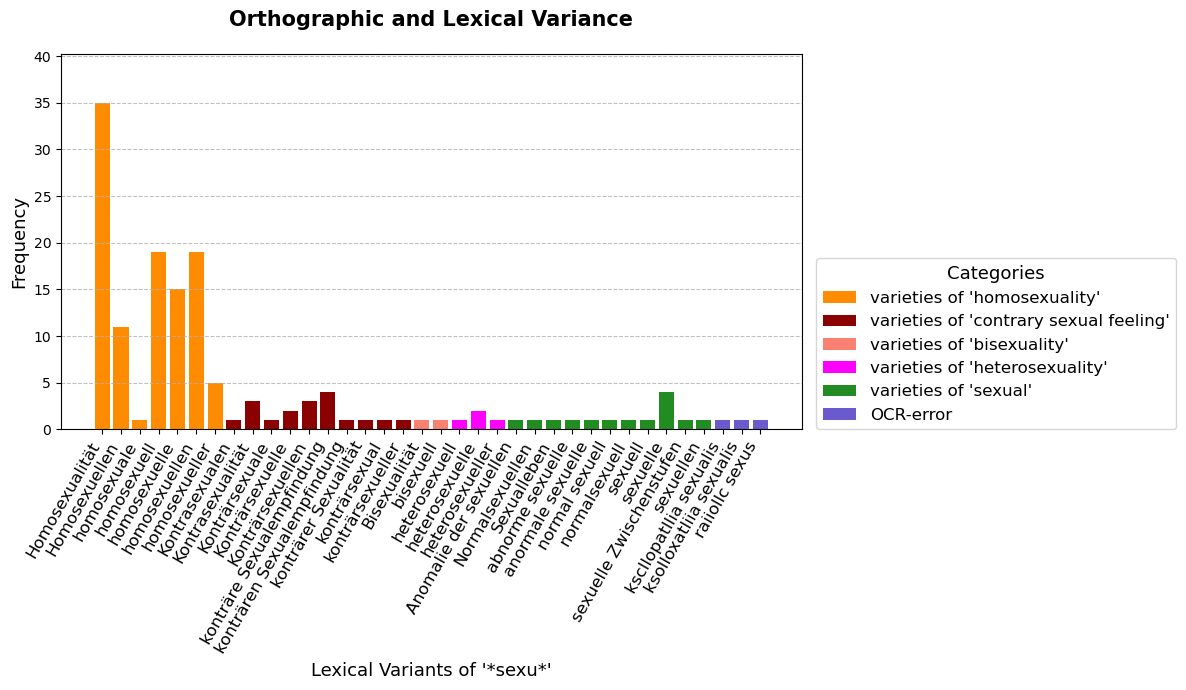

In [14]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df = pd.read_csv("search_terms_match_sexu.csv", sep=";")

# order of categories
category_order = ["varieties of 'homosexuality'", "varieties of 'contrary sexual feeling'", "varieties of 'bisexuality'", "varieties of 'heterosexuality'", "varieties of 'sexual'", "OCR-error"]

df["category"] = pd.Categorical(
    df["category"],
    categories=category_order,
    ordered=True
)

# ordered alphabetically per category
df = df.sort_values(by=["category", "matched_form"])

# color coding
colour_dict = {
    "varieties of 'homosexuality'": "darkorange",
    "varieties of 'bisexuality'": "salmon",
    "varieties of 'contrary sexual feeling'": "darkred",
    "varieties of 'heterosexuality'": "magenta",
    "varieties of 'sexual'": "forestgreen",
    "OCR-error": "slateblue"
}

colours = df["category"].map(colour_dict)

# plotting
plt.figure(figsize=(12, 7))

plt.bar(df["matched_form"], df["count"], color=colours)

max_value = df["count"].max()
plt.ylim(0, max_value * 1.15)

# x-axis
plt.xticks(rotation=60, ha="right", fontsize=12)

plt.xlabel("Lexical Variants of '*sexu*'", fontsize=13)
plt.ylabel("Frequency", fontsize=13)
plt.title(
    "Orthographic and Lexical Variance",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.grid(axis="y", linestyle="--", linewidth=0.75, alpha=0.8)

# legend
legend_elements = [
    Patch(facecolor=colour_dict[cat], label=cat)
    for cat in category_order
]

plt.legend(
    handles=legend_elements,
    title="Categories",
    title_fontsize=13,
    fontsize=12,
    bbox_to_anchor=(1.02, 0),
    loc="lower left",
    borderaxespad=0
)

# save to png
plt.tight_layout()
plt.savefig("orthographic_lexical_variance.png")
plt.show()


### Figure 03: comparison of sentiment values
#### includes
- preparation of files (normalization of sentiment values)
- creation and styling of line-plot
#### csv-files
- normalized files were manually merged into: 'result_sentiment_comparison', which includes: 'id', 'year', 'political_orientation', 'sentiment_per_speech' and 'sentiment_per_context'

### a) normalization of sentiment values for 'result_sentiment_speeches.csv'

In [ ]:
# imports
import pandas as pd
import numpy as np

df = pd.read_csv(
    "result_sentiment_speeches.csv",
    sep=";"
)

# convert into numerics
df["speech_sentiment"] = pd.to_numeric(
    df["speech_sentiment"],
    errors="coerce"
)

df["n_of_countable_words"] = pd.to_numeric(
    df["n_of_countable_words"],
    errors="coerce"
)

# calculate normalized sentiment
df["sentiment_per_speech"] = np.where(
    (df["n_of_countable_words"] > 0),
    df["speech_sentiment"] / df["n_of_countable_words"],
    0
)

# save required columns
df_result = df[
    [
        "id",
        "year",
        "political_orientation",
        "sentiment_per_speech"
    ]
]

# save to csv
df_result.to_csv(
    "result_speech_sentiment_normalized.csv",
    sep=";",
    index=False
)


### b) normalization of sentiment values for 'result_sentiment_contexts'

In [ ]:
# imports
import pandas as pd
import numpy as np

df = pd.read_csv(
    "result_sentiment_contexts.csv",
    sep=";"
)

# convert into numerics
df["speech_sentiment"] = pd.to_numeric(
    df["speech_sentiment"],
    errors="coerce"
)

df["n_of_countable_words"] = pd.to_numeric(
    df["n_of_countable_words"],
    errors="coerce"
)

# group by id
df_grouped = (
    df
    .groupby(["id"], as_index=False)
    .agg({
        "speech_sentiment": "sum",
        "n_of_countable_words": "sum"
    })
)

# calculate normalized sentiment
df_grouped["sentiment_per_context"] = np.where(
    (df_grouped["n_of_countable_words"] > 0),
    df_grouped["speech_sentiment"] /
    df_grouped["n_of_countable_words"],
    0
)

# keep required columns
df_result = df_grouped[
    [
        "id",
        "sentiment_per_context"
    ]
]

# save to csv
df_result.to_csv(
    "result_context_sentiment_normalized.csv",
    sep=";",
    index=False
)


### visualization of sentiment values
#### csv-file
- using manually created file with both normalized values

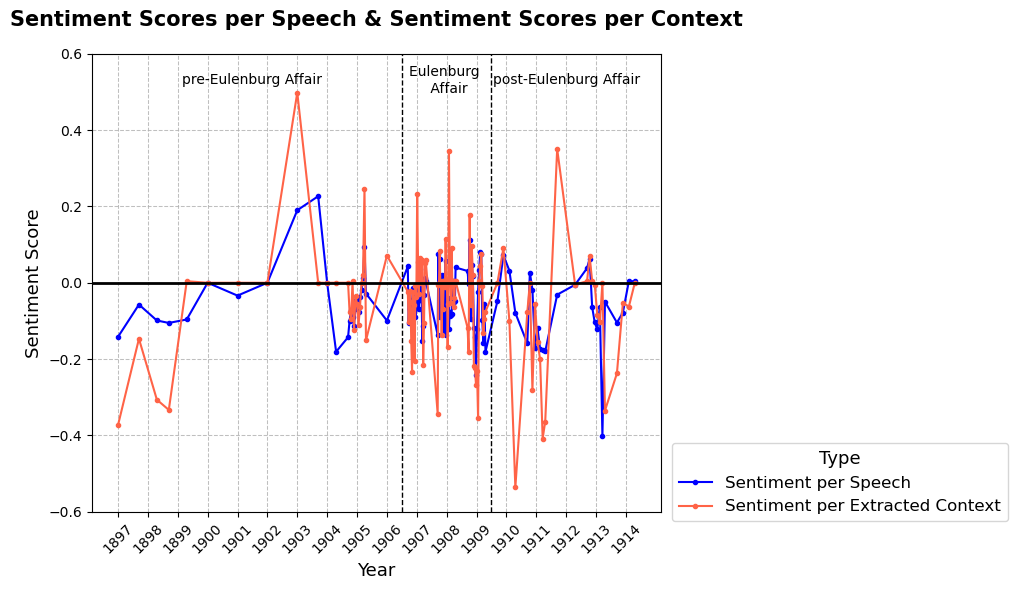

In [21]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("result_sentiment_comparison.csv", sep=";")
df = df.sort_values(["year", "id"])

# spacing of years on x-axis
years = list(range(df["year"].min(), df["year"].max() + 1))
year_to_x = {year: i for i, year in enumerate(years)}

df["x_position"] = np.nan

for year in years:
    
    mask = df["year"] == year
    subset = df[mask]
    base_x = year_to_x[year]
    
    if len(subset) > 0:
        
        if len(subset) > 1:
            offsets = np.linspace(-0.3, 0.3, len(subset))
        else:
            offsets = np.array([0])
        
        df.loc[mask, "x_position"] = base_x + offsets

# plotting
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df["x_position"],
    df["sentiment_per_speech"],
    linestyle="-",
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="Sentiment per Speech",
    color="blue"
)

ax.plot(
    df["x_position"],
    df["sentiment_per_context"],
    linestyle="-",
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="Sentiment per Extracted Context",
    color="tomato"
)

# title
ax.set_title(
    "Sentiment Scores per Speech & Sentiment Scores per Context",
    fontsize=15,
    fontweight="bold",
    pad=20
)

# y-axis
ax.set_ylim(-0.6, 0.6)

ax.axhline(0, color="black", linewidth=2)

ax.grid(True, linestyle="--", linewidth=0.75, alpha=0.8)

# x-axis
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=45)

# phase separators
if 1906 in years:
    ax.axvline(year_to_x[1906] + 0.5, color="black", linestyle="--", linewidth=1)

if 1909 in years:
    ax.axvline(year_to_x[1909] + 0.5, color="black", linestyle="--", linewidth=1)

def get_center(start, end):
    relevant = [year_to_x[y] for y in years if start <= y <= end]
    return np.mean(relevant) if relevant else None

pre_center = get_center(min(years), 1906)
affair_center = get_center(1907, 1909)
post_center = get_center(1910, max(years))

y_text_position = 0.53

if pre_center is not None:
    ax.text(pre_center, y_text_position, "pre-Eulenburg Affair",
            ha="center", va="center", fontsize=10)

if affair_center is not None:
    ax.text(affair_center, y_text_position, "Eulenburg \n Affair",
            ha="center", va="center", fontsize=10)

if post_center is not None:
    ax.text(post_center, y_text_position, "post-Eulenburg Affair",
            ha="center", va="center", fontsize=10)

# labels and legend
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Sentiment Score", fontsize=13)
ax.legend(
    title="Type",
    title_fontsize=13,
    fontsize=12,
    bbox_to_anchor=(1.02, 0.15),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
# save to png
plt.savefig("sentiment_comparison.png")
plt.show()

### Figure 04: heatmap (topic distribution)
#### includes
- creation of the heatmap
- styling of the heatmap
#### csv-file
- contains manually built categories per phase (pre-, during- and post-Eulenburg)


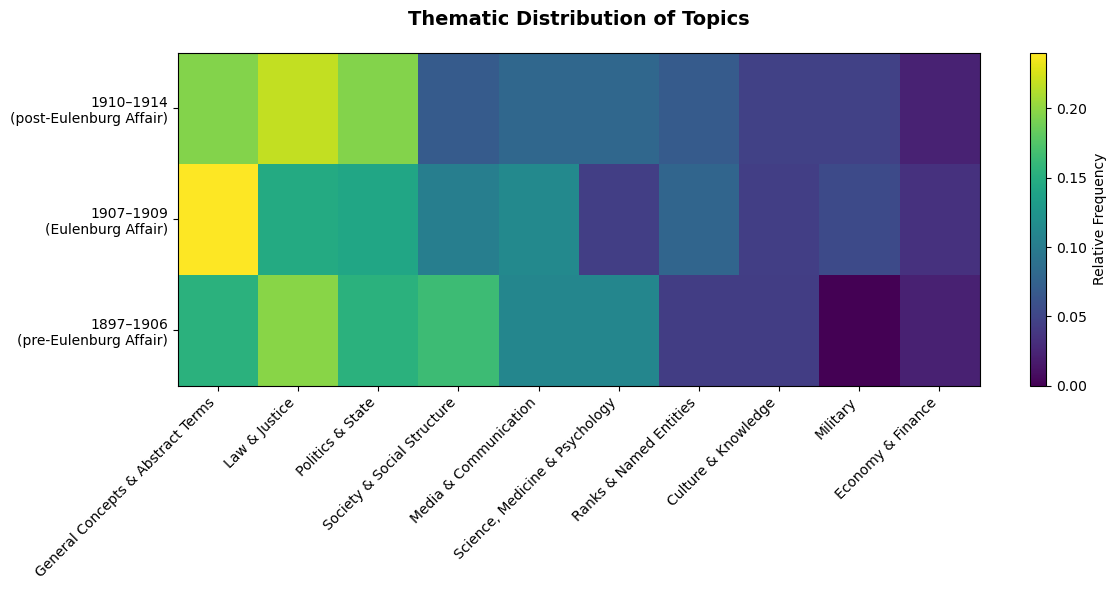

In [1]:
#imports
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("heatmap_topics.csv", sep=";")

# create table
heatmap_data = df.pivot(index="phase", 
                        columns="category", 
                        values="amount_normalised")
heatmap_data = heatmap_data[heatmap_data.sum(axis=0).sort_values(ascending=False).index]

# style
heatmap_data.index = heatmap_data.index.str.replace(" (", "\n(", regex=False)

heatmap_data = heatmap_data.iloc[::-1]
# plotting
plt.figure(figsize=(12,6))
plt.imshow(heatmap_data, aspect="auto", cmap="viridis")

# axis
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45, ha="right")
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)


# legend
plt.colorbar(label="Relative Frequency")

# title
plt.title(
    "Thematic Distribution of Topics",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

#save to png
plt.savefig("heatmap_topic_distribution.png")
plt.show()

### Figure 05: sentiment per topic
#### inlcudes
- creation and styling of line-plot
#### csv-files
- created manually
- include sentiment values and amounts per topic

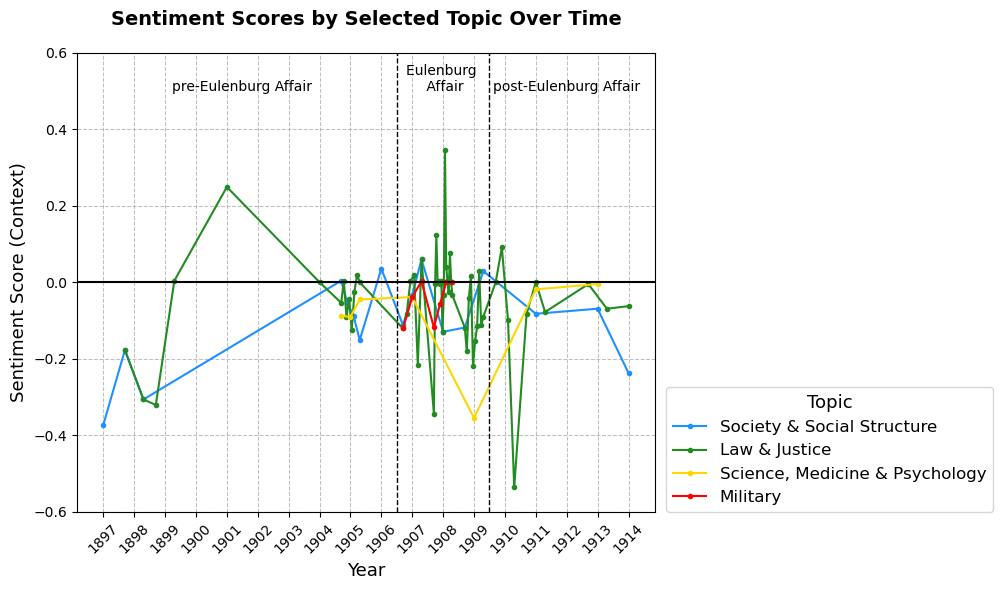

In [18]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

files = {
    "Military": "topic_count_military.csv",
    "Law & Justice": "topic_count_law.csv",
    "Science, Medicine & Psychology": "topic_count_science.csv",
    "Society & Social Structure": "topic_count_society.csv"
}

# prepare data
all_data = []

for topic, file in files.items():
    
    df = pd.read_csv(file, sep=";")
    
    df.columns = df.columns.str.strip().str.lower()

    required_cols = ["id", "year", "sentiment_per_extracted_words", "count"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' not found in {file}")
    
    df = df[df["count"] > 1]
    
    df["topic"] = topic
    
    all_data.append(df)

df_all = pd.concat(all_data, ignore_index=True)

df_all = df_all.sort_values(["year", "id"])

# spacing of years on x-axis
years = list(range(df_all["year"].min(), df_all["year"].max() + 1))
year_to_x = {year: i for i, year in enumerate(years)}


df_all["x_position"] = 0.0

for topic in df_all["topic"].unique():
    
    topic_mask = df_all["topic"] == topic
    
    for year in years:
        mask = topic_mask & (df_all["year"] == year)
        subset = df_all[mask]
        base_x = year_to_x[year]
        
        if len(subset) > 0:
            if len(subset) > 1:
                offsets = np.linspace(-0.3, 0.3, len(subset))
            else:
                offsets = np.array([0])
            
            df_all.loc[mask, "x_position"] = base_x + offsets
            
# color coding
colours = {
    "Military": "red",
    "Society & Social Structure": "dodgerblue",
    "Science, Medicine & Psychology": "gold",
    "Law & Justice": "forestgreen"
}

# plotting
fig, ax = plt.subplots(figsize=(12, 6))

for topic in df_all["topic"].unique():
    subset = df_all[df_all["topic"] == topic]
    
    ax.plot(
        subset["x_position"],
        subset["sentiment_per_extracted_words"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=topic,
        color=colours[topic]
    )
# title
ax.set_title(
    "Sentiment Scores by Selected Topic Over Time",
    fontsize=14,
    fontweight="bold",
    pad=20
)
    
# y-axis
ax.set_ylim(-0.6, 0.6)
ax.axhline(
    y=0, 
    color="black",
    linewidth=1.5)
ax.grid(True, linestyle="--", linewidth=0.75, alpha=0.8)

# x-axis
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=45)

# phase separators
if 1906 in years:
    ax.axvline(year_to_x[1906] + 0.5, linestyle="--", color="black", linewidth=1)

if 1909 in years:
    ax.axvline(year_to_x[1909] + 0.5, linestyle="--", color="black", linewidth=1)

# phase labels
def get_center(start, end):
    relevant = [year_to_x[y] for y in years if start <= y <= end]
    return np.mean(relevant) if relevant else None

pre_center = get_center(min(years), 1906)
affair_center = get_center(1907, 1909)
post_center = get_center(1910, max(years))

y_text_position = 0.50

if pre_center is not None:
    ax.text(pre_center, y_text_position, "pre-Eulenburg Affair", ha="center")

if affair_center is not None:
    ax.text(affair_center, y_text_position, "Eulenburg \n Affair", ha="center")

if post_center is not None:
    ax.text(post_center, y_text_position, "post-Eulenburg Affair", ha="center")

ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Sentiment Score (Context)", fontsize=13)
ax.legend(
    title="Topic",
    title_fontsize=13,
    fontsize=12,
    bbox_to_anchor=(1.02, 0),
    loc="lower left",
    borderaxespad=0
)

plt.tight_layout(rect=[0, 0, 0.85, 1])

#save to png
plt.savefig("sentiment_topic.png")
plt.show()

### Figure 06: sentiment per political orientation
#### includes
- creation and styling of line-plot
#### csv-file
- includes normalized sentiment values and political orientation (same file as in Figure 03)

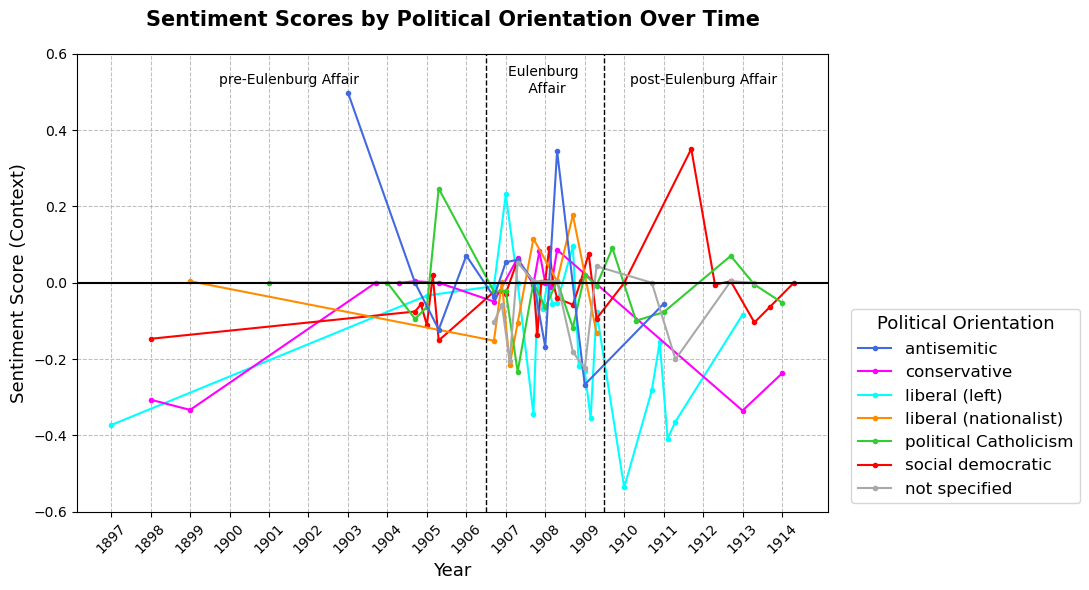

In [5]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("result_sentiment_comparison.csv", sep=";")

df.columns = df.columns.str.strip().str.lower()

df = df.sort_values(["year", "political_orientation", "id"])
df = df.dropna(subset=["political_orientation"])

# spacing for years on x-axis
years = list(range(df["year"].min(), df["year"].max() + 1))
year_to_x = {year: i for i, year in enumerate(years)}

df["x_position"] = 0.0

# distribute speeches within each year and political group
for orientation in df["political_orientation"].unique():
    
    orientation_mask = df["political_orientation"] == orientation
    
    for year in years:
        mask = orientation_mask & (df["year"] == year)
        subset = df[mask]
        base_x = year_to_x[year]
        
        if len(subset) > 0:
            if len(subset) > 1:
                offsets = np.linspace(-0.3, 0.3, len(subset))
            else:
                offsets = np.array([0])
            
            df.loc[mask, "x_position"] = base_x + offsets

# color coding
colours = {
    "antisemitisch": "royalblue",
    "konservativ": "magenta",
    "linksliberal": "aqua",
    "nationalliberal": "darkorange",
    "politischer Katholizismus": "limegreen",
    "sozialdemokratisch": "red",
    "k.A.": "darkgrey"
}


# translation of labels
legend_labels = {
    "antisemitisch": "antisemitic",
    "konservativ": "conservative",
    "linksliberal": "liberal (left)",
    "nationalliberal": "liberal (nationalist)",
    "politischer Katholizismus": "political Catholicism",
    "sozialdemokratisch": "social democratic",
    "k.A.": "not specified"
}
            
# plotting
fig, ax = plt.subplots(figsize=(13, 6))

orientations = df["political_orientation"].unique()

for orientation in orientations:
    subset = df[df["political_orientation"] == orientation]
    
    ax.plot(
        subset["x_position"],
        subset["sentiment_per_context"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=legend_labels[orientation],
        color=colours[orientation]
    )

# y-axis
ax.set_ylim(-0.6, 0.6)

ax.axhline(0, color="black", linewidth=1.5)

ax.grid(True, linestyle="--", linewidth=0.75, alpha=0.8)

# title
ax.set_title(
    "Sentiment Scores by Political Orientation Over Time",
    fontsize=15,
    fontweight="bold",
    pad=20
)

# x-axis
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=45)

# phase separators
if 1906 in years:
    ax.axvline(year_to_x[1906] + 0.5, color="black", linestyle="--", linewidth=1)

if 1909 in years:
    ax.axvline(year_to_x[1909] + 0.5, color="black", linestyle="--", linewidth=1)

def get_center(start, end):
    relevant = [year_to_x[y] for y in years if start <= y <= end]
    return np.mean(relevant) if relevant else None

pre_center = get_center(min(years), 1906)
affair_center = get_center(1907, 1909)
post_center = get_center(1910, max(years))

y_text_position = 0.53

if pre_center is not None:
    ax.text(pre_center, y_text_position, "pre-Eulenburg Affair",
            ha="center", va="center", fontsize=10)

if affair_center is not None:
    ax.text(affair_center, y_text_position, "Eulenburg \n Affair",
            ha="center", va="center", fontsize=10)

if post_center is not None:
    ax.text(post_center, y_text_position, "post-Eulenburg Affair",
            ha="center", va="center", fontsize=10)

# labels and legends
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Sentiment Score (Context)", fontsize=13)
handles, labels = ax.get_legend_handles_labels()

order = [
    "antisemitic",
    "conservative",
    "liberal (left)",
    "liberal (nationalist)",
    "political Catholicism",
    "social democratic",
    "not specified"
]

ordered_handles = [handles[labels.index(l)] for l in order if l in labels]

ax.legend(
    ordered_handles,
    order,
    title="Political Orientation",
    title_fontsize=13,
    fontsize=12,
    bbox_to_anchor=(1.02, 0),
    loc="lower left"
)
plt.tight_layout(rect=[0, 0, 0.85, 1])

# save to png
plt.savefig("sentiment_political_orientation.png")
plt.show()

### Figure 07: sentiment per selectied political orientations (Liberal Left, Conservative, Antisemitic)
#### inlcudes
- creation and styling of line-plot
- focus on three political orientations (liberal left, conservative and antisemitic)
#### csv-file
- includes normalized sentiment values and political orientation (same file as in Figure 03)

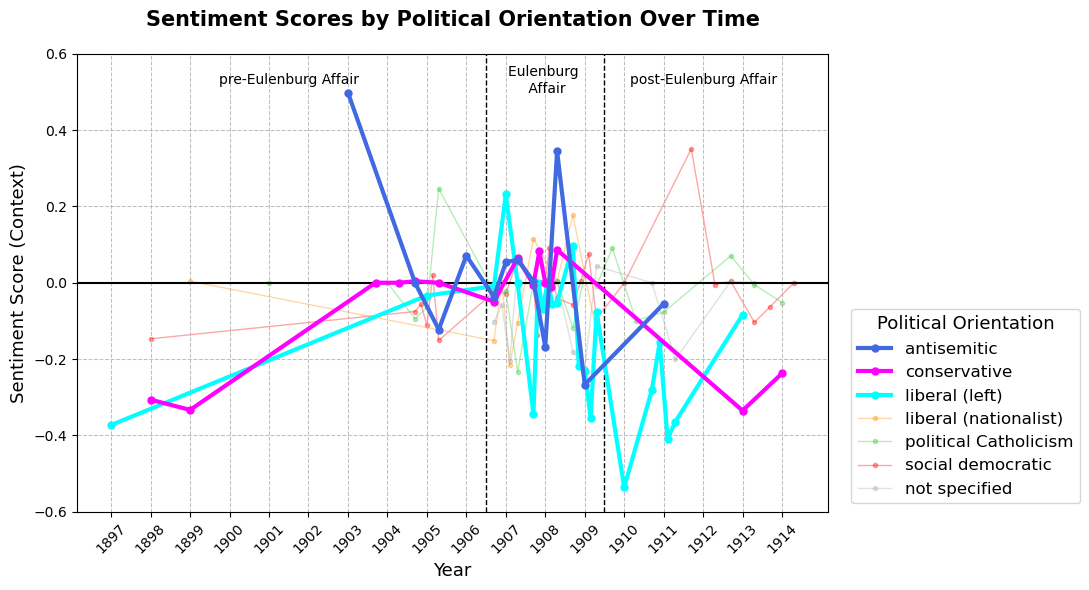

In [10]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("result_sentiment_comparison.csv", sep=";")

df.columns = df.columns.str.strip().str.lower()

df = df.sort_values(["year", "political_orientation", "id"])
df = df.dropna(subset=["political_orientation"])

# spacing for years on x-axis
years = list(range(df["year"].min(), df["year"].max() + 1))
year_to_x = {year: i for i, year in enumerate(years)}

df["x_position"] = 0.0

# distribute speeches within each year and political group
for orientation in df["political_orientation"].unique():
    
    orientation_mask = df["political_orientation"] == orientation
    
    for year in years:
        mask = orientation_mask & (df["year"] == year)
        subset = df[mask]
        base_x = year_to_x[year]
        
        if len(subset) > 0:
            if len(subset) > 1:
                offsets = np.linspace(-0.3, 0.3, len(subset))
            else:
                offsets = np.array([0])
            
            df.loc[mask, "x_position"] = base_x + offsets

# color coding
colours = {
    "antisemitisch": "royalblue",
    "konservativ": "magenta",
    "linksliberal": "aqua",
    "nationalliberal": "darkorange",
    "politischer Katholizismus": "limegreen",
    "sozialdemokratisch": "red",
    "k.A.": "darkgrey"
}


# translation of labels
legend_labels = {
    "antisemitisch": "antisemitic",
    "konservativ": "conservative",
    "linksliberal": "liberal (left)",
    "nationalliberal": "liberal (nationalist)",
    "politischer Katholizismus": "political Catholicism",
    "sozialdemokratisch": "social democratic",
    "k.A.": "not specified"
}
            
# plotting
fig, ax = plt.subplots(figsize=(13, 6))

orientations = df["political_orientation"].unique()

highlight_orientations = [
    "konservativ",
    "linksliberal",
    "antisemitisch"
]

for orientation in orientations:
    subset = df[df["political_orientation"] == orientation]
    
    if orientation in highlight_orientations:
        ax.plot(
            subset["x_position"],
            subset["sentiment_per_context"],
            marker="o",
            markersize=5,
            linewidth=3,
            label=legend_labels[orientation],
            color=colours[orientation],
            zorder=5
        )
    else:
        ax.plot(
            subset["x_position"],
            subset["sentiment_per_context"],
            marker="o",
            markersize=3,
            linewidth=1,
            label=legend_labels[orientation],
            color=colours[orientation],
            alpha=0.35,
            zorder=1
        )
# y-axis
ax.set_ylim(-0.6, 0.6)

ax.axhline(0, color="black", linewidth=1.5)

ax.grid(True, linestyle="--", linewidth=0.75, alpha=0.8)

# title
ax.set_title(
    "Sentiment Scores by Political Orientation Over Time",
    fontsize=15,
    fontweight="bold",
    pad=20
)

# x-axis
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=45)

# phase separators
if 1906 in years:
    ax.axvline(year_to_x[1906] + 0.5, color="black", linestyle="--", linewidth=1)

if 1909 in years:
    ax.axvline(year_to_x[1909] + 0.5, color="black", linestyle="--", linewidth=1)

def get_center(start, end):
    relevant = [year_to_x[y] for y in years if start <= y <= end]
    return np.mean(relevant) if relevant else None

pre_center = get_center(min(years), 1906)
affair_center = get_center(1907, 1909)
post_center = get_center(1910, max(years))

y_text_position = 0.53

if pre_center is not None:
    ax.text(pre_center, y_text_position, "pre-Eulenburg Affair",
            ha="center", va="center", fontsize=10)

if affair_center is not None:
    ax.text(affair_center, y_text_position, "Eulenburg \n Affair",
            ha="center", va="center", fontsize=10)

if post_center is not None:
    ax.text(post_center, y_text_position, "post-Eulenburg Affair",
            ha="center", va="center", fontsize=10)

# labels and legends
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Sentiment Score (Context)", fontsize=13)
handles, labels = ax.get_legend_handles_labels()

order = [
    "antisemitic",
    "conservative",
    "liberal (left)",
    "liberal (nationalist)",
    "political Catholicism",
    "social democratic",
    "not specified"
]

ordered_handles = [handles[labels.index(l)] for l in order if l in labels]

ax.legend(
    ordered_handles,
    order,
    title="Political Orientation",
    title_fontsize=13,
    fontsize=12,
    bbox_to_anchor=(1.02, 0),
    loc="lower left"
)
plt.tight_layout(rect=[0, 0, 0.85, 1])

# save to png
plt.savefig("sentiment_cons_anti_left.png")
plt.show()

### Figure 08: sentiment per selected political orientations (National Liberal, Social Democratic, Political Catholicism)
#### inlcudes
- creation and styling of line-plot
- focus on three political orientations (national liberal, social democratic and political catholicism)
#### csv-file
- includes normalized sentiment values and political orientation (same file as in Figure 03)

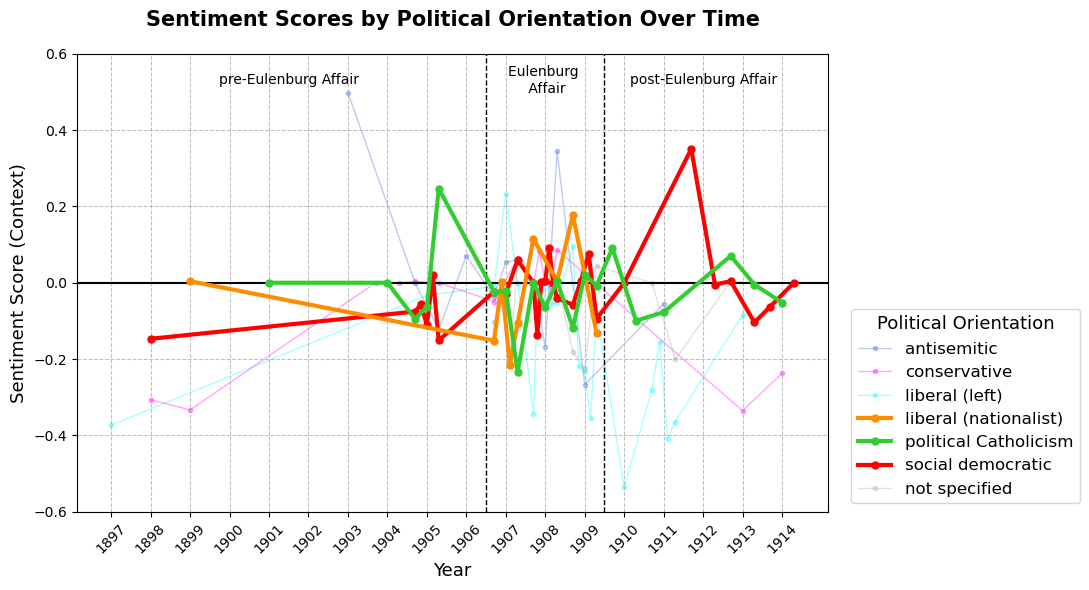

In [11]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("result_sentiment_comparison.csv", sep=";")

df.columns = df.columns.str.strip().str.lower()

df = df.sort_values(["year", "political_orientation", "id"])
df = df.dropna(subset=["political_orientation"])

# spacing for years on x-axis
years = list(range(df["year"].min(), df["year"].max() + 1))
year_to_x = {year: i for i, year in enumerate(years)}

df["x_position"] = 0.0

# distribute speeches within each year and political group
for orientation in df["political_orientation"].unique():
    
    orientation_mask = df["political_orientation"] == orientation
    
    for year in years:
        mask = orientation_mask & (df["year"] == year)
        subset = df[mask]
        base_x = year_to_x[year]
        
        if len(subset) > 0:
            if len(subset) > 1:
                offsets = np.linspace(-0.3, 0.3, len(subset))
            else:
                offsets = np.array([0])
            
            df.loc[mask, "x_position"] = base_x + offsets

# color coding
colours = {
    "antisemitisch": "royalblue",
    "konservativ": "magenta",
    "linksliberal": "aqua",
    "nationalliberal": "darkorange",
    "politischer Katholizismus": "limegreen",
    "sozialdemokratisch": "red",
    "k.A.": "darkgrey"
}


# translation of labels
legend_labels = {
    "antisemitisch": "antisemitic",
    "konservativ": "conservative",
    "linksliberal": "liberal (left)",
    "nationalliberal": "liberal (nationalist)",
    "politischer Katholizismus": "political Catholicism",
    "sozialdemokratisch": "social democratic",
    "k.A.": "not specified"
}
            
# plotting
fig, ax = plt.subplots(figsize=(13, 6))

orientations = df["political_orientation"].unique()

highlight_orientations = [
    "sozialdemokratisch",
    "nationalliberal",
    "politischer Katholizismus"
]

for orientation in orientations:
    subset = df[df["political_orientation"] == orientation]
    
    if orientation in highlight_orientations:
        ax.plot(
            subset["x_position"],
            subset["sentiment_per_context"],
            marker="o",
            markersize=5,
            linewidth=3,
            label=legend_labels[orientation],
            color=colours[orientation],
            zorder=5
        )
    else:
        ax.plot(
            subset["x_position"],
            subset["sentiment_per_context"],
            marker="o",
            markersize=3,
            linewidth=1,
            label=legend_labels[orientation],
            color=colours[orientation],
            alpha=0.35,
            zorder=1
        )
# y-axis
ax.set_ylim(-0.6, 0.6)

ax.axhline(0, color="black", linewidth=1.5)

ax.grid(True, linestyle="--", linewidth=0.75, alpha=0.8)

# title
ax.set_title(
    "Sentiment Scores by Political Orientation Over Time",
    fontsize=15,
    fontweight="bold",
    pad=20
)

# x-axis
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=45)

# phase separators
if 1906 in years:
    ax.axvline(year_to_x[1906] + 0.5, color="black", linestyle="--", linewidth=1)

if 1909 in years:
    ax.axvline(year_to_x[1909] + 0.5, color="black", linestyle="--", linewidth=1)

def get_center(start, end):
    relevant = [year_to_x[y] for y in years if start <= y <= end]
    return np.mean(relevant) if relevant else None

pre_center = get_center(min(years), 1906)
affair_center = get_center(1907, 1909)
post_center = get_center(1910, max(years))

y_text_position = 0.53

if pre_center is not None:
    ax.text(pre_center, y_text_position, "pre-Eulenburg Affair",
            ha="center", va="center", fontsize=10)

if affair_center is not None:
    ax.text(affair_center, y_text_position, "Eulenburg \n Affair",
            ha="center", va="center", fontsize=10)

if post_center is not None:
    ax.text(post_center, y_text_position, "post-Eulenburg Affair",
            ha="center", va="center", fontsize=10)

# labels and legends
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Sentiment Score (Context)", fontsize=13)
handles, labels = ax.get_legend_handles_labels()

order = [
    "antisemitic",
    "conservative",
    "liberal (left)",
    "liberal (nationalist)",
    "political Catholicism",
    "social democratic",
    "not specified"
]

ordered_handles = [handles[labels.index(l)] for l in order if l in labels]

ax.legend(
    ordered_handles,
    order,
    title="Political Orientation",
    title_fontsize=13,
    fontsize=12,
    bbox_to_anchor=(1.02, 0),
    loc="lower left"
)
plt.tight_layout(rect=[0, 0, 0.85, 1])

# save to png
plt.savefig("sentiment_nat_soc_cat.png")
plt.show()